# **TRAINING NOTEBOOK**

---

In this notebook you can run training on the LIBERO datasets for the ActionJEPA VLA.
Follow ALL the instructions in the notebook!


## **IMPORT**

In [7]:
import os
import random
import json
from Dataset.LiberoDataset import LiberoDataset
from model.MLPActionJEPA import MLPActionJEPA
from model.TransformerActionJEPA import TransformerActionJEPA
from training.train import train
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import numpy as np
import cv2
from torch.amp import GradScaler
import pandas as pd
import matplotlib.pyplot as plt

# REPRODUCIBILITY
seed = 46

# Set seed for torch, numpy and random libraries
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(seed)
random.seed(seed)

# Set the devide mode on GPU (if available CUDA for Nvidia and  MPS for Apple Silicon) or CPU
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
 
checkpoints_path = "./checkpoints" 


## HYPERPARAMETERS CONFIG

In [3]:
# Loading the config.json file
with open('config.json', 'r') as f:
    config = json.load(f)

# Hyperparameters definition
NUM_FRAMES = config['num_frames']
NUM_EPOCHS = config['num_epochs']
BATCH_SIZE = config['batch_size']
LEARNING_RATE = config['learning_rate']
LAMBDA_ACTOR = config['lambda_actor']
LAMBDA_REFINER = config['lambda_refiner']
DATASET_TYPE = config['dataset_type']   # it can be "libero_10", "libero_90", "libero_spatial", "libero_object", "libero_goal" or "all"
INTERPOLATION_TYPE = config['interpolation_type']   # it can be "nearest", "linear", "area", "cubic" selection the corresponding method in the interpolation_methods_list
PREPROCESSING_WITH_BACKBONE = config['preprocessing_with_backbone'] # it can be true or false depending if we want to preprocess data extracting feature with VJEPA and CLIP backbones
MAX_LENGTH = config['max_length'] # it is the resulting tokens length after CLIP text encoder
POLICY = config['policy'] # it can be "mlp" or "transformer"
MIXED_PRECISION = config['mixed_precision'] # it can be true or false depending if you want to use float16 (instead of float32) using tensor cores of your gpu

interpolation_dict= {
    "nearest": cv2.INTER_NEAREST,
    "linear": cv2.INTER_LINEAR,
    "area": cv2.INTER_AREA,
    "cubic": cv2.INTER_CUBIC
}

# the get method return the value corresponding to the key INTERPOLATION TYPE, otherwise it return INTER CUBIC method
interpolation = interpolation_dict.get(INTERPOLATION_TYPE, cv2.INTER_CUBIC)

if DATASET_TYPE == "all":
  selected_tasks = ["libero_10", "libero_90", "libero_spatial", "libero_goal", "libero_object"]
else:
  selected_tasks = [DATASET_TYPE]
  
print("="*40)
print(f"✅ Training config created!")
print(f"Epochs: {NUM_EPOCHS} | Frames: {NUM_FRAMES} | Batch Size: {BATCH_SIZE}")
print(f"LR: {LEARNING_RATE} | Lambda Actor: {LAMBDA_ACTOR} | Lambda Refiner: {LAMBDA_REFINER}")
print(f"Interpolation method: {str(interpolation)}")
print(f"Dataset: {selected_tasks}")
print(f"Max Length: {MAX_LENGTH}")
print(f"Policy type: {POLICY}")
print(f"Mixed Precision: {MIXED_PRECISION}")
print("="*40)

✅ Training config created!
Epochs: 50 | Frames: 4 | Batch Size: 16
LR: 0.0001 | Lambda Actor: 1.0 | Lambda Refiner: 1.0
Interpolation method: 1
Dataset: ['libero_goal']
Max Length: 77
Policy type: transformer
Mixed Precision: True


## **DATASET CLASS AND SPLIT**

In [3]:
if DATASET_TYPE == "all":
  selected_tasks = ["libero_10", "libero_90", "libero_spatial", "libero_goal", "libero_object"]
else:
  selected_tasks = [DATASET_TYPE]
  
processed_data_dir ='./processed_data'

dataset = LiberoDataset(data_dir=processed_data_dir,
                        selected_tasks=selected_tasks,
                        num_frames=NUM_FRAMES,
                        stride=1,
                        use_features = PREPROCESSING_WITH_BACKBONE
                        )

train_percentage = 0.7
val_percentage = 0.2

train_size = int(train_percentage*len(dataset))
val_size = int(val_percentage*len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset=dataset, lengths=[train_size, val_size, test_size])

print(f"Total dataset size (windows): {len(dataset)}, Train Size (windows): {len(train_dataset)}, Validation Size (windows): {len(val_dataset)}, Test Size (windows): {len(test_dataset)}")

Total dataset size (windows): 31244, Train Size (windows): 21870, Validation Size (windows): 6248, Test Size (windows): 3126


## **MODEL DEFINITION**

In [4]:
# Path for all the models
vjepa_path = os.path.join(checkpoints_path,"facebook/vjepa2-vitg-fpc64-256")
vjepa_pred_path = os.path.join(checkpoints_path,"facebook/jepa-wms/vjepa2_ac_droid.pth.tar/vjepa2_ac_droid.pth.tar")
clip_path = os.path.join(checkpoints_path,"openai/clip-vit-large-patch14")

if POLICY == "mlp":
    model = MLPActionJEPA(
        vjepa_encoder_path=vjepa_path,
        vjepa_predictor_path=vjepa_pred_path,
        clip_model_path=clip_path,
        num_frames=NUM_FRAMES,
        use_backbone = not(PREPROCESSING_WITH_BACKBONE),
        device=device
    ).to(device)
else:
    model = TransformerActionJEPA(
        vjepa_encoder_path=vjepa_path,
        vjepa_predictor_path=vjepa_pred_path,
        clip_model_path=clip_path,
        num_frames=NUM_FRAMES,
        use_backbone = not(PREPROCESSING_WITH_BACKBONE),
        device=device
    ).to(device)

model.print_model_info()

MODEL INFO:

LEARNABLE ACTION TOKEN:
torch.Size([1, 1, 512])
PREDICTOR LAYERS:
PredictorAC
PredictorAC(
  (predictor): VisionTransformerPredictorAC(
    (predictor_embed): Linear(in_features=1408, out_features=1024, bias=True)
    (action_encoder): Linear(in_features=7, out_features=1024, bias=True)
    (predictor_blocks): ModuleList(
      (0-23): 24 x Block(
        (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): RoPEAttention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features

## **TRAIN**

In [ ]:
with open('config.json', 'r') as f:
    config = json.load(f)

# Name of the directory for the results
results_dir_path = "./results"
os.makedirs(results_dir_path, exist_ok=True)

# Definition of the Categorical Cross Entropy Loss
loss_fn = nn.MSELoss()
# Definition of the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr = LEARNING_RATE)

if MIXED_PRECISION:
    scaler = GradScaler()
else:
    scaler = None

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=16,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)

training_dir_path = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    num_epochs=NUM_EPOCHS,
    config=config,
    device=device,
    scaler=scaler,
    results_dir_path=results_dir_path,
    lambda_actor=LAMBDA_ACTOR,
    lambda_refiner=LAMBDA_REFINER,
)


EPOCH: 1/50 - LR: 0.0000100


Validation: 100%|██████████| 391/391 [01:36<00:00,  4.05it/s, loss=0.0389, actor loss=0.0199, refiner loss=0.0189]


--------------------------------------------------------------------------------
TRAIN      | Tot Loss: 0.1136 | Actor: 0.0565 | Refiner: 0.0571
VALIDATION | Tot Loss: 0.0536 | Actor: 0.0271 | Refiner: 0.0265
METRICS  (Validation)  | XYZ Err: 0.1146 | Gripper Err: 0.1393 | Cosine Sim Orientation: 0.4243
--------------------------------------------------------------------------------
Best model! Saving in: ./results/2026_04_23__16_44/best_model.pth

EPOCH: 2/50 - LR: 0.0000280


Validation: 100%|██████████| 391/391 [01:35<00:00,  4.10it/s, loss=0.0232, actor loss=0.0090, refiner loss=0.0141]


--------------------------------------------------------------------------------
TRAIN      | Tot Loss: 0.0474 | Actor: 0.0235 | Refiner: 0.0238
VALIDATION | Tot Loss: 0.0332 | Actor: 0.0166 | Refiner: 0.0166
METRICS  (Validation)  | XYZ Err: 0.0901 | Gripper Err: 0.0835 | Cosine Sim Orientation: 0.5228
--------------------------------------------------------------------------------
Best model! Saving in: ./results/2026_04_23__16_44/best_model.pth

EPOCH: 3/50 - LR: 0.0000460


...

--------------------------------------------------------------------------------
TRAIN      | Tot Loss: 0.0032 | Actor: 0.0016 | Refiner: 0.0016
VALIDATION | Tot Loss: 0.0101 | Actor: 0.0050 | Refiner: 0.0050
METRICS  (Validation)  | XYZ Err: 0.0472 | Gripper Err: 0.0388 | Cosine Sim Orientation: 0.7118
--------------------------------------------------------------------------------

EPOCH: 49/50 - LR: 0.0000015


Validation: 100%|██████████| 391/391 [01:35<00:00,  4.11it/s, loss=0.0044, actor loss=0.0022, refiner loss=0.0022]


--------------------------------------------------------------------------------
TRAIN      | Tot Loss: 0.0032 | Actor: 0.0016 | Refiner: 0.0016
VALIDATION | Tot Loss: 0.0100 | Actor: 0.0050 | Refiner: 0.0049
METRICS  (Validation)  | XYZ Err: 0.0471 | Gripper Err: 0.0379 | Cosine Sim Orientation: 0.7115
--------------------------------------------------------------------------------
Best model! Saving in: ./results/2026_04_23__16_44/best_model.pth

EPOCH: 50/50 - LR: 0.0000011


Validation: 100%|██████████| 391/391 [01:35<00:00,  4.12it/s, loss=0.0042, actor loss=0.0021, refiner loss=0.0020]


--------------------------------------------------------------------------------
TRAIN      | Tot Loss: 0.0032 | Actor: 0.0016 | Refiner: 0.0016
VALIDATION | Tot Loss: 0.0099 | Actor: 0.0050 | Refiner: 0.0049
METRICS  (Validation)  | XYZ Err: 0.0468 | Gripper Err: 0.0375 | Cosine Sim Orientation: 0.7113
--------------------------------------------------------------------------------
Best model! Saving in: ./results/2026_04_23__16_44/best_model.pth


## PLOTS

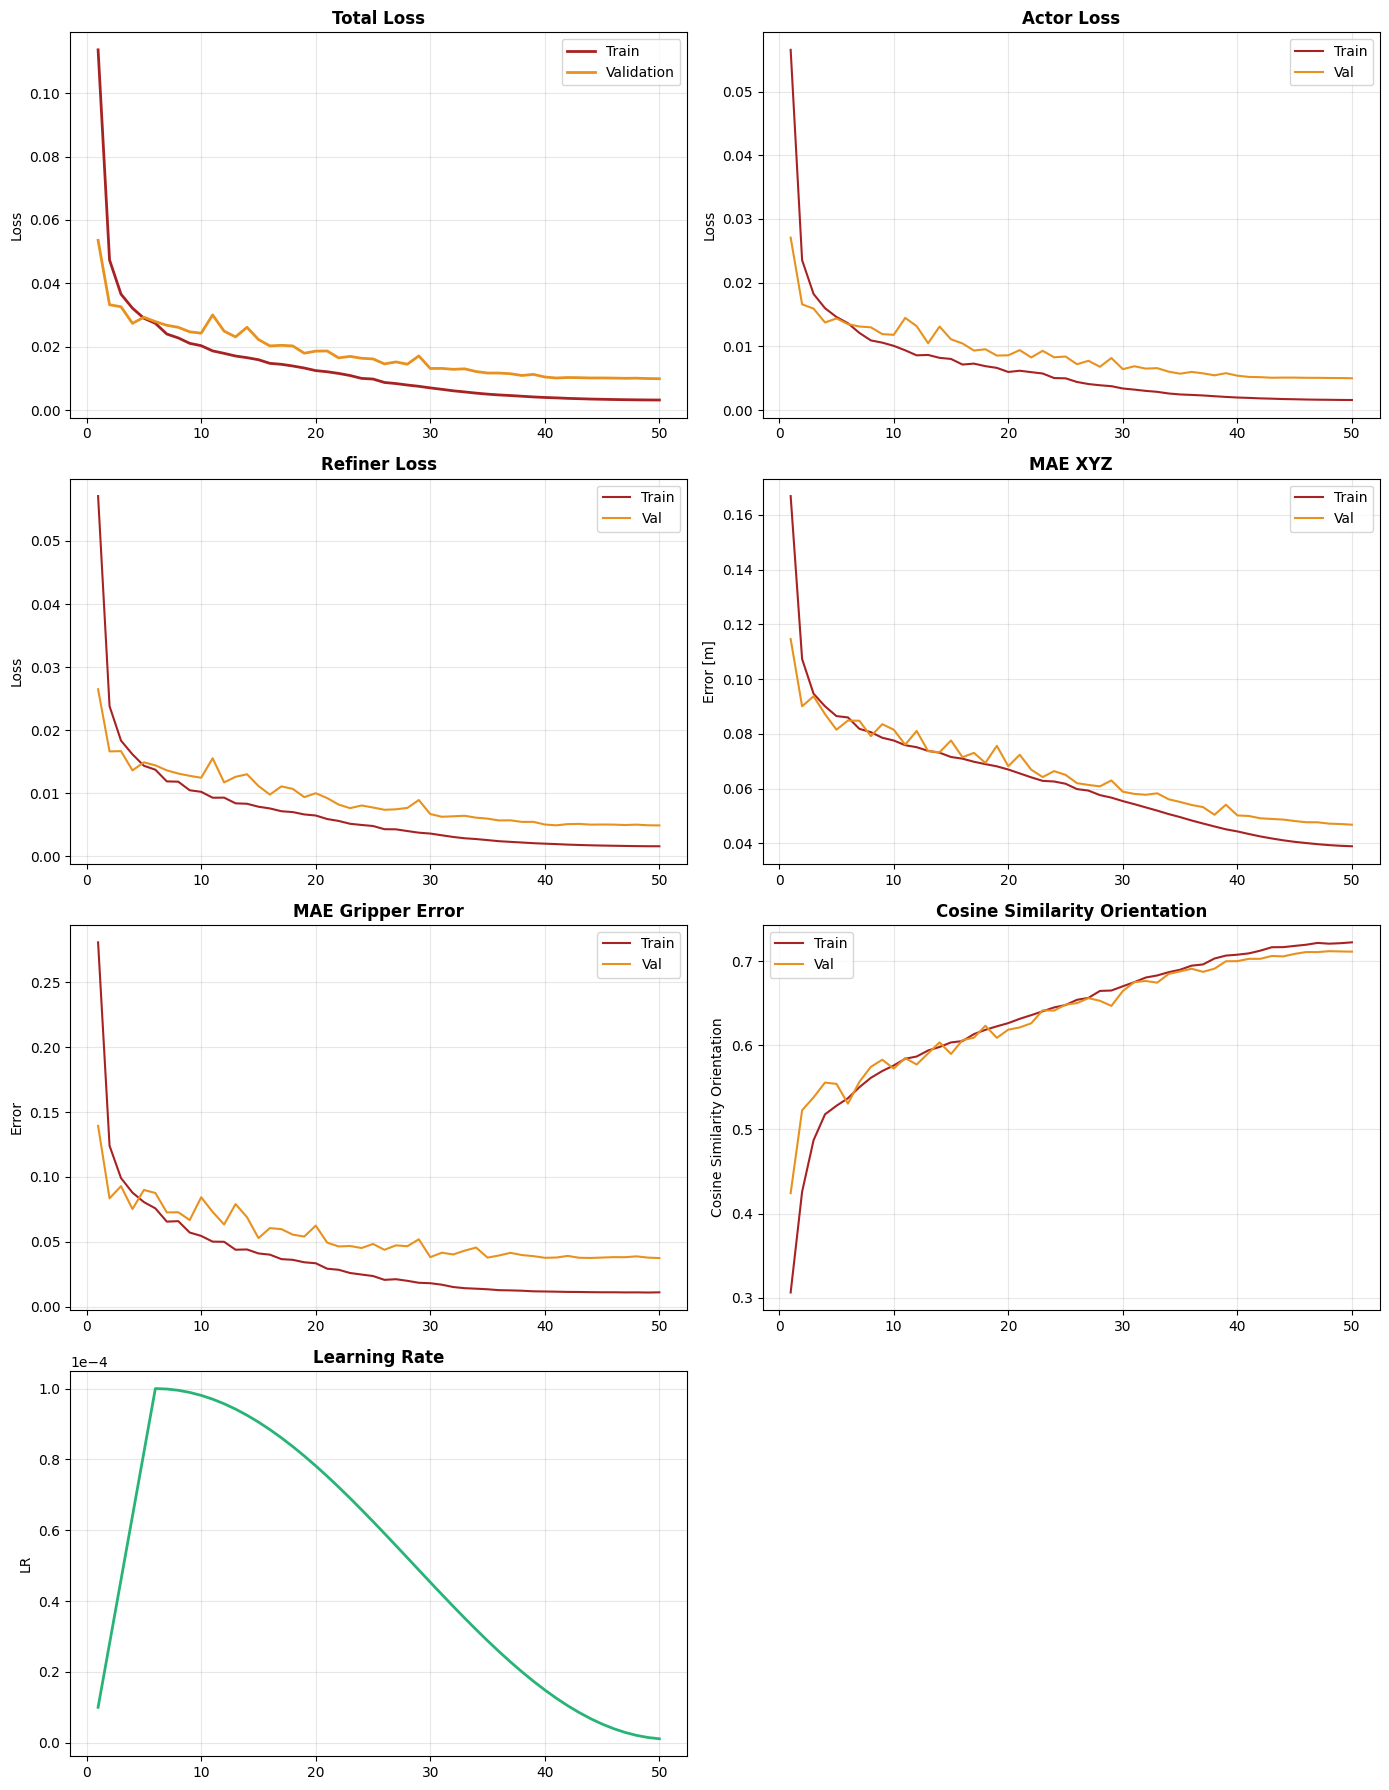

In [14]:
training_dir_path = "./results/2026_04_23__16_44"
metrics_path = os.path.join(training_dir_path, 'metrics.csv')

df = pd.read_csv(metrics_path)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()
plt.style.use('seaborn-v0_8-muted')

c_train = "#a72222"
c_val = "#e8911e"

axes[0].plot(df['Epoch'], df['loss_train'], label='Train', linewidth=2, color=c_train)
axes[0].plot(df['Epoch'], df['loss_val'], label='Validation', linewidth=2, color=c_val)
axes[0].set_title('Total Loss', fontweight='bold')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df['Epoch'], df['loss_actor_train'], label='Train', color=c_train)
axes[1].plot(df['Epoch'], df['loss_actor_val'], label='Val', color=c_val)
axes[1].set_title('Actor Loss', fontweight='bold')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(df['Epoch'], df['loss_refiner_train'], label='Train', color=c_train)
axes[2].plot(df['Epoch'], df['loss_refiner_val'], label='Val', color=c_val)
axes[2].set_title('Refiner Loss', fontweight='bold')
axes[2].set_ylabel('Loss')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

axes[3].plot(df['Epoch'], df['mae_xyz_train'], label='Train', color=c_train)
axes[3].plot(df['Epoch'], df['mae_xyz_val'], label='Val', color=c_val)
axes[3].set_title('MAE XYZ', fontweight='bold')
axes[3].set_ylabel('Error [m]')
axes[3].grid(True, alpha=0.3)
axes[3].legend()

axes[4].plot(df['Epoch'], df['mae_gripper_train'], label='Train', color=c_train)
axes[4].plot(df['Epoch'], df['mae_gripper_val'], label='Val', color=c_val)
axes[4].set_title('MAE Gripper Error', fontweight='bold')
axes[4].set_ylabel('Error')
axes[4].grid(True, alpha=0.3)
axes[4].legend()

axes[5].plot(df['Epoch'], df['cosim_ori_train'], label='Train', color=c_train)
axes[5].plot(df['Epoch'], df['cosim_ori_val'], label='Val', color=c_val)
axes[5].set_title('Cosine Similarity Orientation', fontweight='bold')
axes[5].set_ylabel('Cosine Similarity Orientation')
axes[5].grid(True, alpha=0.3)
axes[5].legend()

axes[6].plot(df['Epoch'], df['lr_train'], color="#28b377", linewidth=2)
axes[6].set_title('Learning Rate', fontweight='bold')
axes[6].set_ylabel('LR')
axes[6].grid(True, alpha=0.3)
axes[6].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

fig.delaxes(axes[7])

plt.tight_layout()
plt.savefig(os.path.join(training_dir_path,'plots.png'), dpi=300)
plt.show()